# FIT5217 Assignment 2 - Task 1

**Name:** Jili Chen  
**Student ID:** 35423757

**AI Usage Declaration:** Option 3. I used generative AI tools to support coding, debugging, understanding implementation choices, and drafting analysis. I reviewed, tested, and take responsibility for the submitted work.

## Table of Contents

1. T1.1 Data Preprocessing
2. T1.2 Baseline RNN Encoder-Decoder
3. T1.3 Bahdanau Attention
4. T1.4 Analysis and Reflection


In [1]:
import sys
import os
import json
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display, Markdown

sys.path.append('..')
ROOT = Path('..').resolve()

from src.utils import set_seed

set_seed(42)

is_colab = 'google.colab' in sys.modules
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {ROOT}')
print(f'Environment: {"Colab" if is_colab else "local/Jupyter"}')
print(f'Python executable: {sys.executable}')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')
print('Random seed fixed at 42.')


Project root: /Users/nili/Desktop/fit5217_a2
Environment: local/Jupyter
Python executable: /opt/anaconda3/bin/python
PyTorch version: 2.8.0
Device: cpu
Random seed fixed at 42.


## T1.1 Data Preprocessing

The preprocessing pipeline converts the JSON-list `Ingredients` and `Recipe` columns into integer ID sequences for the encoder-decoder. Each list is joined with a single space and fed to a Unicode-aware regex tokenizer that lowercases text, isolates punctuation as separate tokens, and keeps numeric expressions such as fractions and decimals as single tokens. A single shared vocabulary is built from both ingredients and recipes using the training split only, which exploits the strong lexical overlap between food items, units, and cooking actions. Four special tokens use fixed IDs: `<PAD>=0`, `<UNK>=1`, `<SOS>=2`, and `<EOS>=3`. The selected threshold is `min_freq=5`, based on dev-set OOV trade-offs.

In [2]:
with open(ROOT / 'outputs' / 'vocab.pkl', 'rb') as f:
    vocab_state = pickle.load(f)

word2idx = vocab_state['word2idx']
idx2word = {idx: token for token, idx in word2idx.items()}

assert '<PAD>' in word2idx and word2idx['<PAD>'] in idx2word
assert '<UNK>' in word2idx and word2idx['<UNK>'] in idx2word
assert '<SOS>' in word2idx and word2idx['<SOS>'] in idx2word
assert '<EOS>' in word2idx and word2idx['<EOS>'] in idx2word

for token in ['<PAD>', '<UNK>', '<SOS>', '<EOS>']:
    idx = word2idx[token]
    assert idx2word[idx] == token

print('All 4 special tokens verified.')
print({token: word2idx[token] for token in ['<PAD>', '<UNK>', '<SOS>', '<EOS>']})


All 4 special tokens verified.
{'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}


In [3]:
with open(ROOT / 'outputs' / 'min_freq_comparison.json', 'r') as f:
    min_freq_data = json.load(f)

rows = []
for item in min_freq_data['rows']:
    rows.append({
        'min_freq': item['min_freq'],
        'vocab_size': item['vocab_size'],
        'dev_oov_occ_pct': item['dev']['occ_pct'],
        'dev_oov_type_pct': item['dev']['type_pct'],
        'test_oov_occ_pct': item['test']['occ_pct'],
        'test_oov_type_pct': item['test']['type_pct'],
        'chosen': item['chosen'],
    })
comparison_df = pd.DataFrame(rows)
display(comparison_df)

chosen = comparison_df.loc[comparison_df['min_freq'] == 5].iloc[0]
print(f"Final vocabulary size: {int(chosen['vocab_size']):,}")
print('Selected min_freq: 5')
print(f"Dev OOV rate: {chosen['dev_oov_occ_pct']:.4f}% occurrence-level; {chosen['dev_oov_type_pct']:.4f}% type-level")

display(Markdown('**Justification.** I selected `min_freq=5` because it keeps the vocabulary compact while preserving very high dev coverage. Compared with `min_freq=3`, it removes many rare tokens but increases occurrence-level dev OOV only slightly. Compared with `min_freq=10`, it avoids a sharper coverage loss and gives each retained token enough examples for a more stable learned embedding.'))


,min_freq,vocab_size,dev_oov_occ_pct,dev_oov_type_pct,test_oov_occ_pct,test_oov_type_pct,chosen
0,3,8446,0.0981,2.9624,0.0834,2.6500,False
1,5,6733,0.1352,3.9878,0.1164,3.7412,True
2,10,5175,0.1973,5.9628,0.1877,5.9236,False


Final vocabulary size: 6,733
Selected min_freq: 5
Dev OOV rate: 0.1352% occurrence-level; 3.9878% type-level


**Justification.** I selected `min_freq=5` because it keeps the vocabulary compact while preserving very high dev coverage. Compared with `min_freq=3`, it removes many rare tokens but increases occurrence-level dev OOV only slightly. Compared with `min_freq=10`, it avoids a sharper coverage loss and gives each retained token enough examples for a more stable learned embedding.

## T1.2 Baseline RNN Encoder-Decoder

The baseline model is a one-layer GRU encoder-decoder trained with teacher forcing and no attention. The encoder embeds the ingredient sequence and passes the final hidden state to the decoder. The decoder consumes the gold previous token during training and predicts the next recipe token. Training uses cross-entropy loss with `<PAD>` ignored, gradient clipping at 1.0, Adam with learning rate 0.001, batch size 128, embedding dimension 128, hidden dimension 256, dropout 0.1, and early stopping monitored on dev loss. This gives a compact from-scratch baseline before introducing attention.

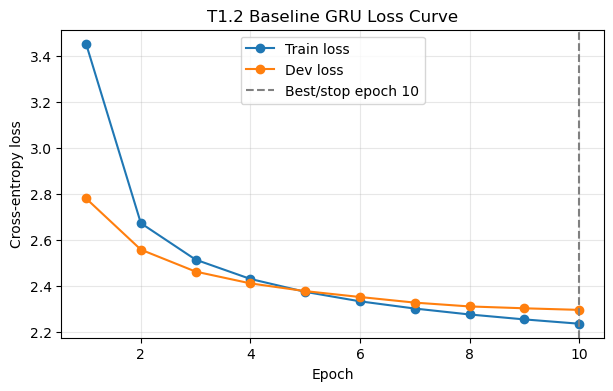

Baseline checkpoint config:
{
  "epochs": 10,
  "batch_size": 128,
  "max_tgt_len": 80,
  "embed_size": 128,
  "hidden_size": 256,
  "num_layers": 1,
  "dropout": 0.1,
  "lr": 0.001,
  "clip": 1.0,
  "patience": 3,
  "vocab_size": 6733,
  "seed": 42,
  "cell": "GRU",
  "bidirectional": false,
  "attention": null
}
Final train loss: 2.2342
Best dev loss: 2.2945 at epoch 10


In [4]:
baseline_ckpt = torch.load(ROOT / 'checkpoints' / 't1_baseline' / 'best.pt', map_location='cpu', weights_only=False)
baseline_train = baseline_ckpt['train_losses']
baseline_dev = baseline_ckpt['dev_losses']
baseline_epochs = np.arange(1, len(baseline_train) + 1)
baseline_best_epoch = int(baseline_ckpt['epoch'])

plt.figure(figsize=(7, 4))
plt.plot(baseline_epochs, baseline_train, marker='o', label='Train loss')
plt.plot(baseline_epochs, baseline_dev, marker='o', label='Dev loss')
plt.axvline(baseline_best_epoch, color='gray', linestyle='--', label=f'Best/stop epoch {baseline_best_epoch}')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('T1.2 Baseline GRU Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Baseline checkpoint config:')
print(json.dumps(baseline_ckpt['config'], indent=2, default=str))
print(f"Final train loss: {baseline_train[-1]:.4f}")
print(f"Best dev loss: {min(baseline_dev):.4f} at epoch {baseline_best_epoch}")


In [5]:
test_df = pd.read_csv(ROOT / 'data' / 'raw' / 'test.csv')
with open(ROOT / 'outputs' / 'predictions' / 't1_baseline_test.json', 'r') as f:
    baseline_preds = json.load(f)

assert len(baseline_preds) == len(test_df) == 1081
preview_rows = []
for i in range(3):
    preview_rows.append({
        'Title': test_df.loc[i, 'Title'],
        'Ingredients': test_df.loc[i, 'Ingredients'],
        'Gold recipe': baseline_preds[i]['gold'],
        'Baseline generated': baseline_preds[i]['prediction'],
    })
display(pd.DataFrame(preview_rows))

baseline_metrics = {'BLEU-4': 0.0741, 'METEOR': 0.2415, 'BERTScore': 0.8745}
print('T1.2 baseline test metrics:')
for key, value in baseline_metrics.items():
    print(f'{key}: {value:.4f}')


,Title,Ingredients,Gold recipe,Baseline generated
0,"""Too Good"" Fruit Dip","[""1 (8 oz.) pkg. cream cheese"", ""1 small jar M...",whip cream cheese with mixer until smooth . bl...,mix together and serve with fresh fruit .
1,Sloppy Joes,"[""1 lb. ground beef"", ""1/2 c. onions, cut up (...",combine all ingredients . cook 30 minutes . se...,brown beef and onions . drain . add remaining ...
2,Lemon Congealed Salad,"[""1 large box lemon jello"", ""1 large can crush...",drain juice from pineapple and save . prepare ...,mix jello and pineapple . let set until firm ....


T1.2 baseline test metrics:
BLEU-4: 0.0741
METEOR: 0.2415
BERTScore: 0.8745


The baseline model learns frequent cooking patterns and often produces grammatical short instructions, but the outputs are generic. In the displayed examples, it tends to reuse broad phrases such as mixing, simmering, or serving rather than preserving every ingredient-specific action from the gold recipe. This is expected for a vanilla encoder-decoder because the full source sequence is compressed into a single final hidden state. For longer ingredient lists, that bottleneck makes it difficult to remember all constraints. The BLEU-4 score is modest, while METEOR and BERTScore show that the baseline still captures some semantic overlap and common procedural language.

## T1.3 Bahdanau Attention

Bahdanau attention removes the strict single-vector bottleneck of vanilla encoder-decoders by allowing the decoder to look back at all encoder hidden states at every generation step. For each target step $t$, the model compares the previous decoder state $s_{t-1}$ with each encoder state $h_i$ via an additive scoring function:

$$
\text{score}(s_{t-1}, h_i) = v^T \tanh(W_s s_{t-1} + W_h h_i).
$$

Here $W_s$ and $W_h$ are learned projection matrices that map decoder and encoder states into a shared attention space, and $v$ is a learned vector that collapses this space to a scalar. The use of $\tanh$ and addition (rather than a dot product, as in Luong attention) makes the alignment differentiable and allows decoder and encoder states with mismatched dimensions to interact.

The scores are normalized across source positions using a masked softmax, so that padding positions receive zero probability mass:

$$
\alpha_{t,i} = \frac{\exp(\text{score}(s_{t-1}, h_i))}{\sum_{j=1}^{T_{\text{src}}} \exp(\text{score}(s_{t-1}, h_j))}.
$$

These attention weights form a distribution over ingredient tokens, indicating which source positions the decoder relies on when producing the current output token. Finally, the context vector is the weighted sum of encoder states:

$$
c_t = \sum_{i=1}^{T_{\text{src}}} \alpha_{t,i} h_i.
$$

The decoder receives the current target embedding concatenated with $c_t$, so generation conditions on both the previous recipe token and a dynamic source summary. This implementation uses only basic PyTorch layers and tensor operations, with no built-in attention module.


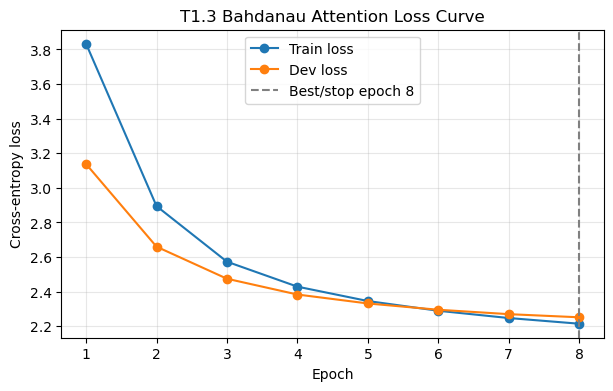

Attention checkpoint config:
{
  "epochs": 8,
  "batch_size": 128,
  "max_tgt_len": 80,
  "embed_size": 128,
  "hidden_size": 256,
  "num_layers": 1,
  "dropout": 0.1,
  "lr": 0.001,
  "clip": 1.0,
  "patience": 3,
  "vocab_size": 6733,
  "seed": 42,
  "cell": "GRU",
  "bidirectional": false,
  "attention": "bahdanau_manual"
}
Final train loss: 2.2142
Best dev loss: 2.2514 at epoch 8


In [6]:
attention_ckpt = torch.load(ROOT / 'checkpoints' / 't1_attention' / 'best.pt', map_location='cpu', weights_only=False)
attention_train = attention_ckpt['train_losses']
attention_dev = attention_ckpt['dev_losses']
attention_epochs = np.arange(1, len(attention_train) + 1)
attention_best_epoch = int(attention_ckpt['epoch'])

plt.figure(figsize=(7, 4))
plt.plot(attention_epochs, attention_train, marker='o', label='Train loss')
plt.plot(attention_epochs, attention_dev, marker='o', label='Dev loss')
plt.axvline(attention_best_epoch, color='gray', linestyle='--', label=f'Best/stop epoch {attention_best_epoch}')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('T1.3 Bahdanau Attention Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Attention checkpoint config:')
print(json.dumps(attention_ckpt['config'], indent=2, default=str))
print(f"Final train loss: {attention_train[-1]:.4f}")
print(f"Best dev loss: {min(attention_dev):.4f} at epoch {attention_best_epoch}")


In [7]:
with open(ROOT / 'outputs' / 'predictions' / 't1_attention_test.json', 'r') as f:
    attention_preds = json.load(f)

assert len(attention_preds) == len(test_df) == 1081
preview_rows = []
for i in range(3):
    preview_rows.append({
        'Title': test_df.loc[i, 'Title'],
        'Ingredients': test_df.loc[i, 'Ingredients'],
        'Gold recipe': attention_preds[i]['gold'],
        'Attention generated': attention_preds[i]['prediction'],
    })
display(pd.DataFrame(preview_rows))

attention_metrics = {'BLEU-4': 0.0905, 'METEOR': 0.2538, 'BERTScore': 0.8772}
print('T1.3 attention test metrics:')
for key, value in attention_metrics.items():
    print(f'{key}: {value:.4f}')


,Title,Ingredients,Gold recipe,Attention generated
0,"""Too Good"" Fruit Dip","[""1 (8 oz.) pkg. cream cheese"", ""1 small jar M...",whip cream cheese with mixer until smooth . bl...,mix all ingredients together . serve with fres...
1,Sloppy Joes,"[""1 lb. ground beef"", ""1/2 c. onions, cut up (...",combine all ingredients . cook 30 minutes . se...,brown meat and onions . add mustard and catsup...
2,Lemon Congealed Salad,"[""1 large box lemon jello"", ""1 large can crush...",drain juice from pineapple and save . prepare ...,mix jello with 1 cup boiling water . add pinea...


T1.3 attention test metrics:
BLEU-4: 0.0905
METEOR: 0.2538
BERTScore: 0.8772


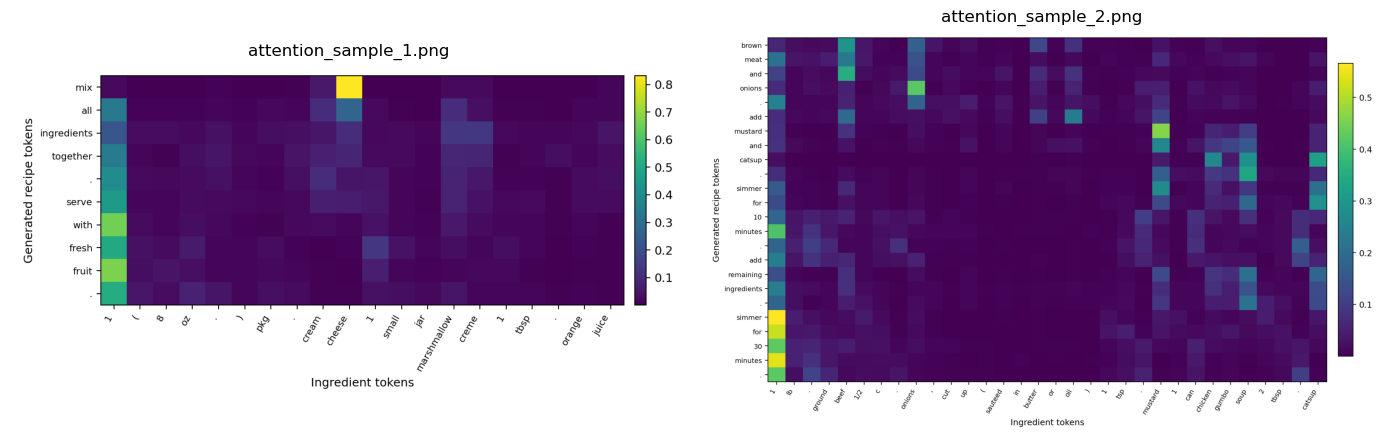

Displayed attention heatmaps:
/Users/nili/Desktop/fit5217_a2/outputs/attention_heatmaps/attention_sample_1.png
/Users/nili/Desktop/fit5217_a2/outputs/attention_heatmaps/attention_sample_2.png


In [8]:
from PIL import Image

heatmap_paths = [
    ROOT / 'outputs' / 'attention_heatmaps' / 'attention_sample_1.png',
    ROOT / 'outputs' / 'attention_heatmaps' / 'attention_sample_2.png',
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path in zip(axes, heatmap_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(path.name)
plt.tight_layout()
plt.show()
print('Displayed attention heatmaps:')
for path in heatmap_paths:
    print(path)


The attention model improves all three test metrics, especially BLEU-4, which suggests better local word choice and phrase overlap. The heatmaps show that attention can recover direct source-target links for content words. In sample 2, source tokens such as mustard, catsup, and onions align with the corresponding generated tokens, which is exactly the behavior expected from Bahdanau attention. Sample 1 is less clean: some non-content output tokens fall back to high weight on the first source positions. This indicates that attention helps ingredient grounding but does not fully solve generic generation or function-word alignment in a small from-scratch model.

## T1.4 Analysis and Reflection

In [9]:
baseline_config = baseline_ckpt['config']
attention_config = attention_ckpt['config']
hparam_rows = []
for name, cfg in [('T1.2 Baseline', baseline_config), ('T1.3 Attention', attention_config)]:
    hparam_rows.append({
        'Model': name,
        'Cell': cfg.get('cell'),
        'Attention': cfg.get('attention') or 'None',
        'Bidirectional encoder': cfg.get('bidirectional'),
        'Embedding dim': cfg.get('embed_size'),
        'Hidden dim': cfg.get('hidden_size'),
        'Layers': cfg.get('num_layers'),
        'Dropout': cfg.get('dropout'),
        'Learning rate': cfg.get('lr'),
        'Batch size': cfg.get('batch_size'),
        'Max target length': cfg.get('max_tgt_len'),
        'Gradient clip': cfg.get('clip'),
        'Epochs run': cfg.get('epochs'),
    })
display(pd.DataFrame(hparam_rows))


,Model,Cell,Attention,Bidirectional encoder,Embedding dim,Hidden dim,Layers,Dropout,Learning rate,Batch size,Max target length,Gradient clip,Epochs run
0,T1.2 Baseline,GRU,None,False,128,256,1,0.1,0.001,128,80,1.0,10
1,T1.3 Attention,GRU,bahdanau_manual,False,128,256,1,0.1,0.001,128,80,1.0,8


In [10]:
comparison = pd.DataFrame([
    {'Model': 'T1.2 Baseline', 'BLEU-4': 0.0741, 'METEOR': 0.2415, 'BERTScore': 0.8745},
    {'Model': 'T1.3 Attention', 'BLEU-4': 0.0905, 'METEOR': 0.2538, 'BERTScore': 0.8772},
    {'Model': 'Delta (improvement)', 'BLEU-4': '+22.1%', 'METEOR': '+5.1%', 'BERTScore': '+0.3%'},
])
display(comparison)


,Model,BLEU-4,METEOR,BERTScore
0,T1.2 Baseline,0.0741,0.2415,0.8745
1,T1.3 Attention,0.0905,0.2538,0.8772
2,Delta (improvement),+22.1%,+5.1%,+0.3%


In [11]:
sample_indices = [0, 1, 2]
qual_rows = []
commentary = {
    0: 'Both models produce a generic dip instruction; attention is slightly more concise but still misses several gold steps.',
    1: 'Both models capture the sloppy-joe style simmering pattern; attention includes more source ingredients such as mustard and catsup.',
    2: 'The generated recipes remain shorter than gold, showing the common RNN tendency toward safe generic procedures.',
}
for i in sample_indices:
    qual_rows.append({
        'Ingredients': test_df.loc[i, 'Ingredients'],
        'Gold recipe': baseline_preds[i]['gold'],
        'Baseline generated': baseline_preds[i]['prediction'],
        'Attention generated': attention_preds[i]['prediction'],
        'Commentary': commentary[i],
    })
display(pd.DataFrame(qual_rows))


,Ingredients,Gold recipe,Baseline generated,Attention generated,Commentary
0,"[""1 (8 oz.) pkg. cream cheese"", ""1 small jar M...",whip cream cheese with mixer until smooth . bl...,mix together and serve with fresh fruit .,mix all ingredients together . serve with fres...,Both models produce a generic dip instruction;...
1,"[""1 lb. ground beef"", ""1/2 c. onions, cut up (...",combine all ingredients . cook 30 minutes . se...,brown beef and onions . drain . add remaining ...,brown meat and onions . add mustard and catsup...,Both models capture the sloppy-joe style simme...
2,"[""1 large box lemon jello"", ""1 large can crush...",drain juice from pineapple and save . prepare ...,mix jello and pineapple . let set until firm ....,mix jello with 1 cup boiling water . add pinea...,The generated recipes remain shorter than gold...


Both models show steadily decreasing train and dev losses, so the training runs were stable. The baseline ran for 10 epochs and the attention model for 8 epochs; in both cases, the best checkpoint is the final recorded epoch because dev loss continued to improve. There is no obvious overfitting pattern in these curves: train loss is lower than dev loss, but the dev curve keeps moving downward rather than turning upward. The attention model starts with a higher first-epoch dev loss than the baseline, which is expected because it has more moving parts and computes a new alignment distribution at each target step. By the end, however, its dev loss is lower and its test metrics are better. This supports the main hypothesis of Task 1: even a simple manually implemented Bahdanau mechanism helps a from-scratch encoder-decoder preserve source information more effectively.